# Aerial Object Classification (Bird vs Drone)
End-to-end notebook

## 1. Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

In [3]:
import sys
print(sys.executable)

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\python.exe


In [4]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## 2. Paths

In [5]:
train_path = "data/train"
val_path = "data/val"
test_path = "data/test"

## 3. Data Generators

In [6]:
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=15,
zoom_range=0.2,
horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
train_path,
target_size=(224, 224),
batch_size=32,
class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
val_path,
target_size=(224, 224),
batch_size=32,
class_mode='binary'
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.


## 4. Sample Images

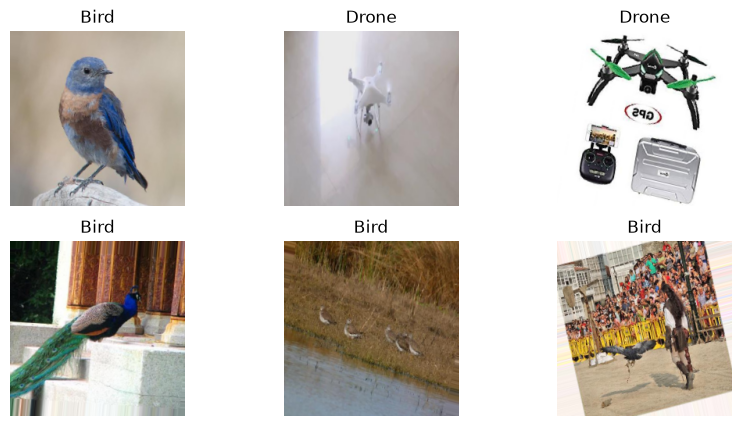

In [7]:
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
 plt.subplot(2,3,i+1)
 plt.imshow(images[i])
 plt.title("Bird" if labels[i]==0 else "Drone")
 plt.axis("off")
plt.show()

## 5. Model

In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = Sequential([
base_model,
GlobalAveragePooling2D(),
Dense(128, activation='relu'),
Dropout(0.4),
Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Callbacks

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

## 7. Training

In [10]:
history = model.fit(
train_data,
validation_data=val_data,
epochs=50,
callbacks=[early_stop, checkpoint]
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.8681 - loss: 0.2860

84/84 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9298 - loss: 0.1712 - val_accuracy: 0.9683 - val_loss: 0.0867
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9662 - loss: 0.0943

84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 751ms/step - accuracy: 0.9722 - loss: 0.0764 - val_accuracy: 0.9819 - val_loss: 0.0695
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 671ms/step - accuracy: 0.9771 - loss: 0.0581

84/84 ━━━━━━━━━━━━━━━━━━━━ 64s 763ms/step - accuracy: 0.9771 - loss: 0.0579 - val_accuracy: 0.9706 - val_loss: 0.0691
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.9829 - loss: 0.0489

84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 754ms/step - accuracy: 0.9835 - loss: 0.0502 - val_accuracy: 0.9729 - val_loss: 0.0685
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 746ms/step - accuracy: 0.9899 - loss: 0.0333 - val_accuracy: 0.9729 - val_loss: 0.0872
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.9847 - loss: 0.0369

84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 749ms/step - accuracy: 0.9820 - loss: 0.0459 - val_accuracy: 0.9751 - val_loss: 0.0648
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 63s 752ms/step - accuracy: 0.9929 - loss: 0.0244 - val_accuracy: 0.9683 - val_loss: 0.0822
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 77s 915ms/step - accuracy: 0.9929 - loss: 0.0246 - val_accuracy: 0.9683 - val_loss: 0.0935
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 837ms/step - accuracy: 0.9917 - loss: 0.0226 - val_accuracy: 0.9751 - val_loss: 0.0782


## 8. Plots

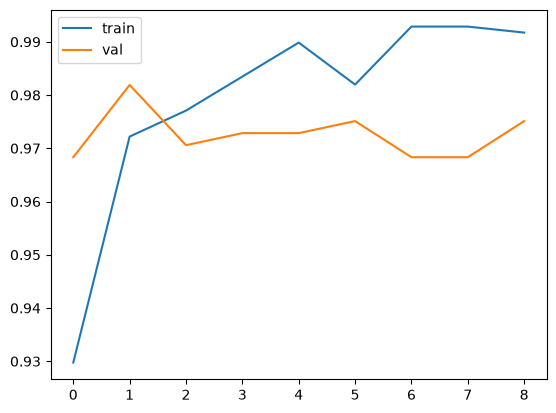

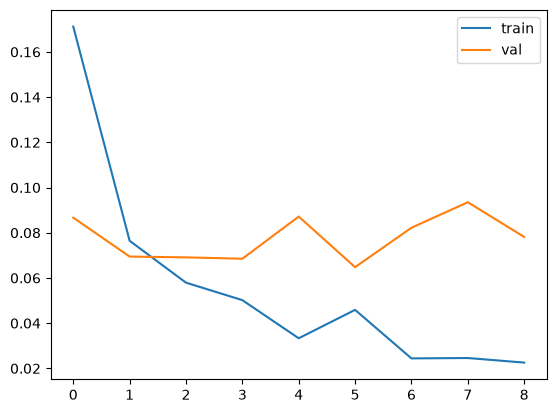

In [11]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

## 9. Test Evaluation

In [12]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
test_path,
target_size=(224,224),
batch_size=32,
class_mode='binary',
shuffle=False
)

loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

Found 215 images belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 612ms/step - accuracy: 0.9767 - loss: 0.0599
Test Accuracy: 0.9767441749572754


## 10. Predictions

In [13]:
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = test_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 651ms/step


## 11. Report

In [14]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       121
           1       0.98      0.97      0.97        94

    accuracy                           0.98       215
   macro avg       0.98      0.98      0.98       215
weighted avg       0.98      0.98      0.98       215



## 12. Confusion Matrix

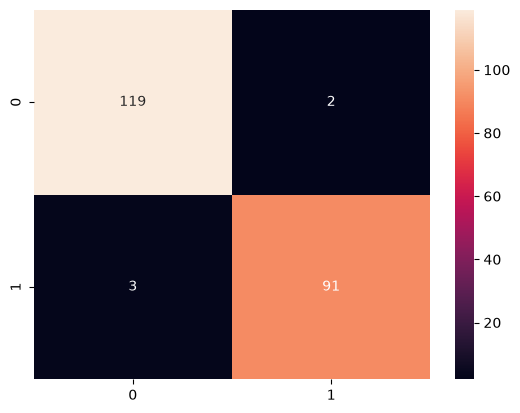

In [15]:
cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## 13. Save Model

In [18]:
model.save("final_model.h5")